In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class multivariate_data_simulator():
    def __init__(self, n_sources, groups_of_dep_var, n_states, sigma, fs, length):
        self.n_sources = n_sources if isinstance(n_sources, list) else groups_of_dep_var*[n_sources]
        self.groups_of_dep_var = groups_of_dep_var
        self.sigma = sigma
        self.fs = fs
        self.length = length
        self.n_settings = n_states
        self.source_frequencies = []
        self.emission_matrix = []
        for source, group in zip(n_sources, groups_of_dep_var):
            setting_freq = np.zeros((n_states, source))
            self.emission_matrix.append(np.random.normal(0, 1, (group, source)))
            for i in range(n_states):
                setting_freq[i,:] = np.random.uniform(1, 50, source)
            self.source_frequencies.append(setting_freq)
    
    def generate(self, n_samples, return_sources = False):
        # Generate the independent variables
        t = np.repeat(np.expand_dims(np.arange(0, self.length, 1/self.fs), axis = 0), n_samples, axis = 0)
        # Generate a random phase shift per sample
        phase_shift = np.expand_dims(np.random.uniform(0, 2*np.pi, n_samples), 1)
        # Generate the dependent variables
        y = np.zeros((n_samples, round(self.length*self.fs) , np.sum(self.groups_of_dep_var)))
        states = np.random.randint(0, self.n_settings, n_samples)

        if return_sources:
            assert len(self.groups_of_dep_var) == 1, "return_sources only works for a single group of sources"
            sources = np.zeros((n_samples, round(self.length*self.fs), self.n_sources[0]))
            emission_matrices = np.zeros((n_samples, self.groups_of_dep_var[0], self.n_sources[0]))

        j = 0
        i = 0
        for group in self.groups_of_dep_var:
            for k in range(self.n_sources[i]):
                y[:, :, j:j+group] += np.expand_dims(np.sin(np.expand_dims(self.source_frequencies[i][states, k],1) * t + phase_shift), 2) @ np.expand_dims(self.emission_matrix[i][:, k], 0)
                if return_sources:
                    sources[:, :, k] = np.sin(np.expand_dims(self.source_frequencies[i][states, k],1) * t + phase_shift)
                    emission_matrices[:, :, k] = self.emission_matrix[i][:, k]
            i+=1
            j+=group
        # Add noise
        y += np.random.normal(0, self.sigma, (n_samples, round(self.length*self.fs), np.sum(self.groups_of_dep_var)))
        # randomly shuffle the variables
        if return_sources:
            return y, sources, emission_matrices
        else:
            idx = np.arange(np.sum(self.groups_of_dep_var))
            np.random.shuffle(idx)
            return y[:, :, idx]

In [14]:
n_var = 10
n_sources = 5
datagenerator = multivariate_data_simulator([n_sources], [n_var], 20, 0.5, 1000, 1)

data, sources, emission_matrices = datagenerator.generate(1000, return_sources = True)

In [4]:
n_var = 10
n_sources = 5
datagenerator = multivariate_data_simulator([n_sources, n_sources], [n_var, 2], 20, 0.5, 1000, 1)

mult_dep_data = datagenerator.generate(1000, return_sources = False)

In [15]:
n_points_to_plot = 1
data_to_plot = np.random.choice(data.shape[0], n_points_to_plot, replace = False)

/var/folders/xl/fct1_y7d2tn5g3_7qcd7m89h0000gn/T/ipykernel_71631/3941028612.py:18: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


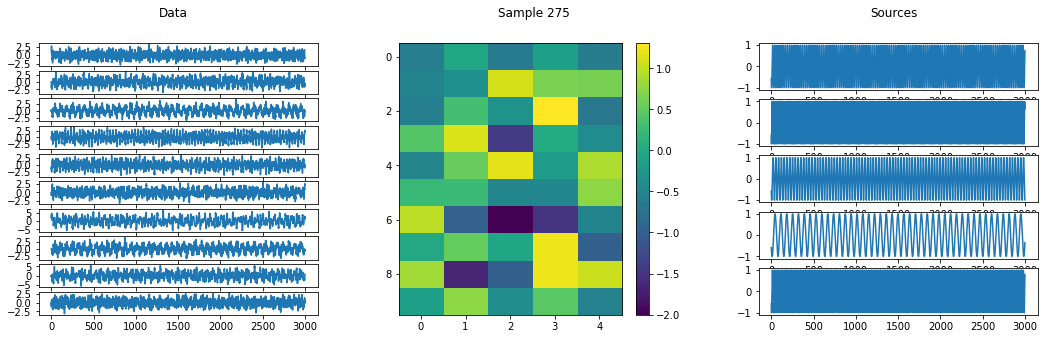

In [16]:
data_sources, vars, titles = [data, emission_matrices, sources], [n_var, 1, n_sources], ['Data', '', 'Sources']

fig = plt.figure(figsize=(15, n_points_to_plot*5))
subfigs = fig.subfigures(n_points_to_plot, 1, squeeze=False)

for k in range(n_points_to_plot):
    subfig_ax = subfigs[k][0].subfigures(1, 3)
    subfigs[k][0].suptitle('Sample {}'.format(data_to_plot[k]))
    for i in range(3):
        ax = subfig_ax[i].subplots(vars[i], 1, squeeze=False)
        subfig_ax[i].suptitle('{}'.format(titles[i]))
        if i == 1:
            pos = ax[0][0].imshow(data_sources[i][data_to_plot[k], :, :], aspect = 'auto')
            fig.colorbar(pos, ax=ax[0][0])
            continue
        for j in range(vars[i]):
            ax[j][0].plot(data_sources[i][data_to_plot[k], :, j])
plt.tight_layout()
plt.show()

/var/folders/xl/fct1_y7d2tn5g3_7qcd7m89h0000gn/T/ipykernel_71631/1239970970.py:20: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


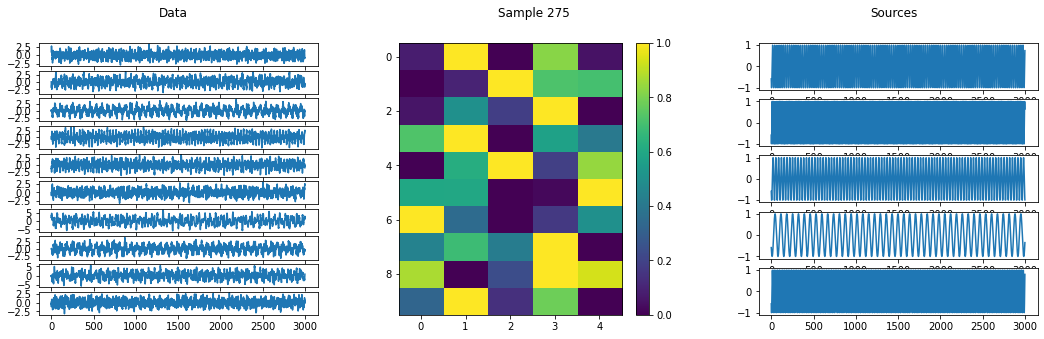

In [17]:
data_sources, vars, titles = [data, emission_matrices, sources], [n_var, 1, n_sources], ['Data', '', 'Sources']

fig = plt.figure(figsize=(15, n_points_to_plot*5))
subfigs = fig.subfigures(n_points_to_plot, 1, squeeze=False)

for k in range(n_points_to_plot):
    subfig_ax = subfigs[k][0].subfigures(1, 3)
    subfigs[k][0].suptitle('Sample {}'.format(data_to_plot[k]))
    for i in range(3):
        ax = subfig_ax[i].subplots(vars[i], 1, squeeze=False)
        subfig_ax[i].suptitle('{}'.format(titles[i]))
        if i == 1:
            # normalize emission matrix
            emission = (data_sources[i][data_to_plot[k], :, :] - np.expand_dims(np.min(data_sources[i][data_to_plot[k], :, :], 1), 1)) / np.expand_dims(np.max(data_sources[i][data_to_plot[k], :, :], 1) - np.min(data_sources[i][data_to_plot[k], :, :], 1), 1)
            pos = ax[0][0].imshow(emission, aspect = 'auto')
            fig.colorbar(pos, ax=ax[0][0])
            continue
        for j in range(vars[i]):
            ax[j][0].plot(data_sources[i][data_to_plot[k], :, j])
plt.tight_layout()
plt.show()

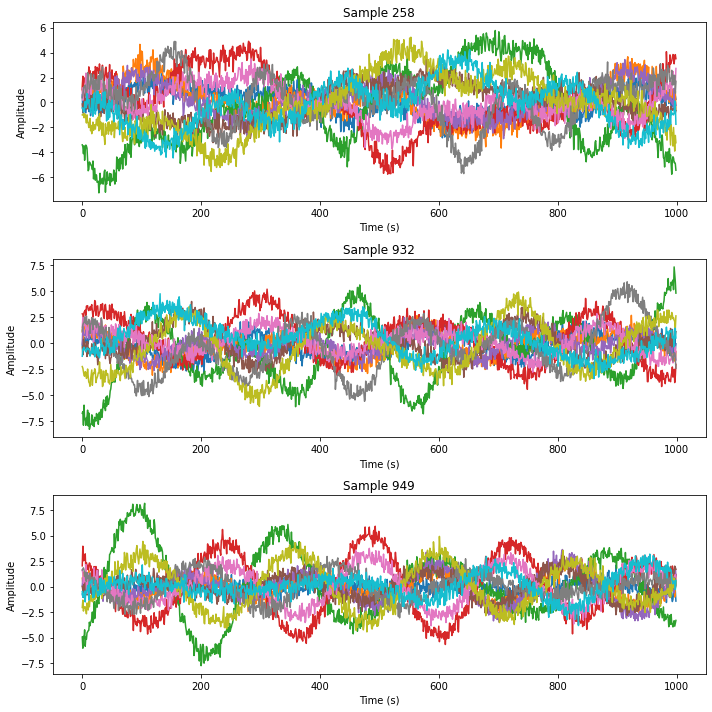

In [11]:
n_points_to_plot = 3
data_to_plot = np.random.choice(data.shape[0], n_points_to_plot, replace = False)

fig, ax = plt.subplots(n_points_to_plot, 1, figsize = (10, 10))

for k in range(n_points_to_plot):
    ax[k].plot(data[data_to_plot[k], :, :])
    ax[k].set_title('Sample {}'.format(data_to_plot[k]))
    ax[k].set_xlabel('Time (s)')
    ax[k].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()